<center><h1>HW6</h1></center>

Name: xxx
<br>
Github Username: xxx
<br>
USC ID: xxx

## 1. Tree-Based Methods

Import packages

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.stats import bootstrap
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
# from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc as sklearn_auc
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn import tree
from sklearn.tree import _tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

### (a) Download the APS Failure data

In [2]:
trainDf = pd.read_csv('../Data/aps_failure_training_set.csv',skiprows=20,na_values=['na'],low_memory=False)
testDf = pd.read_csv('../Data/aps_failure_test_set.csv',skiprows=20,na_values=['na'],low_memory=False)
trainDf['class'] = trainDf['class'].map({'neg':0,'pos':1}).astype(int)
testDf['class'] = testDf['class'].map({'neg':0,'pos':1}).astype(int)

In [3]:
trainDf

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,0,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,0,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,0,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,0,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,0,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,0,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,0,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


### (b) Data Preparation

#### (i) Research what types of techniques are usually used

deletion, simple statistical imputation, KNN imputation, regression, MICE   
I choose simple statistical imputation, median 

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
trainDf[trainDf.columns.drop('class')] = imputer.fit_transform(trainDf.drop(columns='class'))
testDf[testDf.columns.drop('class')]  = imputer.transform(testDf.drop(columns='class'))


#### (ii) Calculate the coefficient of variation

In [5]:
cv = trainDf.drop('class', axis=1).apply(lambda x:np.std(x, ddof=1)/np.mean(x), axis=0)

#### (iii) Plot a correlation matrix

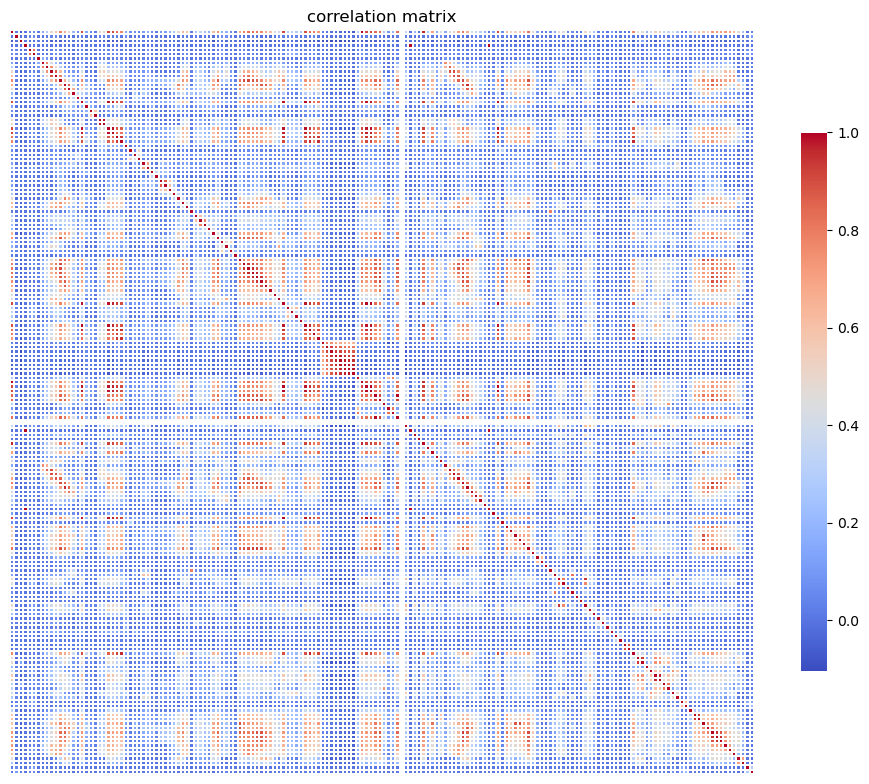

In [6]:
feature = trainDf.drop('class', axis=1)

corr_matrix = feature.corr(method='pearson')  
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            linewidths=0.2,
            square=True,
            cbar_kws={"shrink": 0.7},
            xticklabels=False, 
            yticklabels=False)
plt.title("correlation matrix")
plt.show()

#### (iv) Make scatter plots and box plots

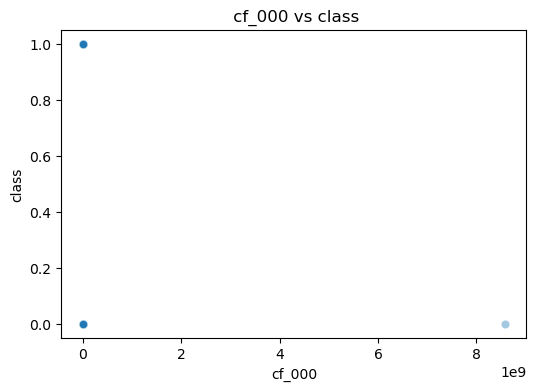

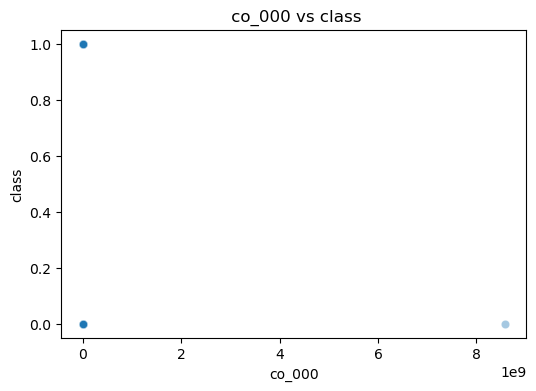

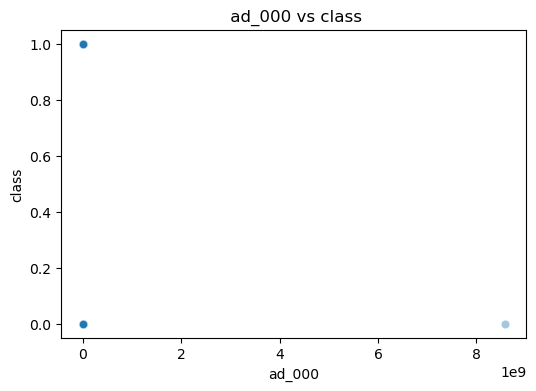

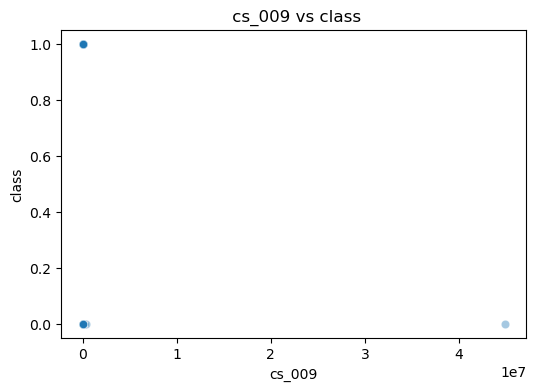

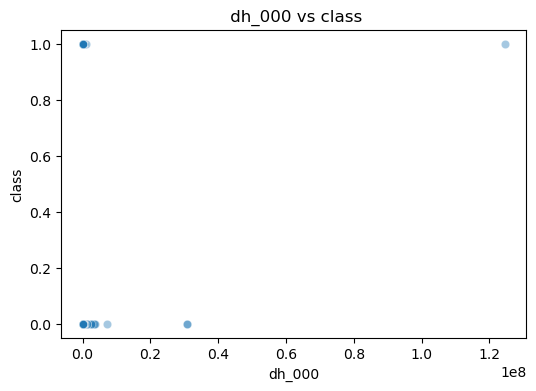

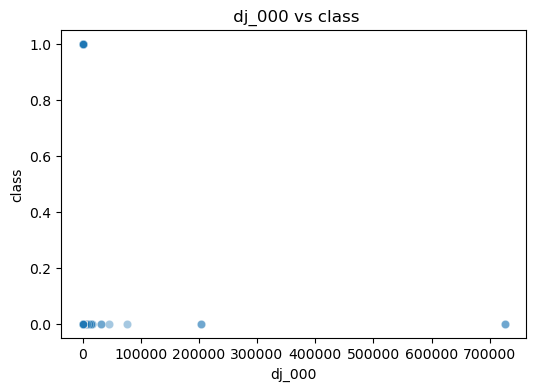

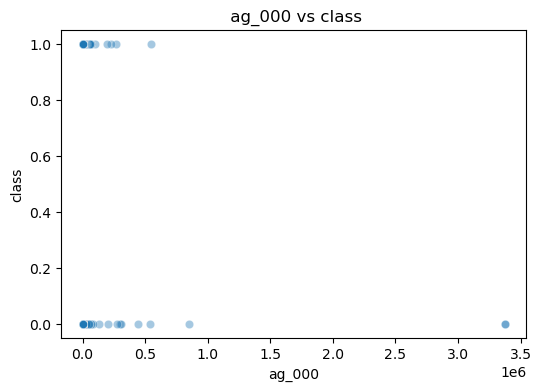

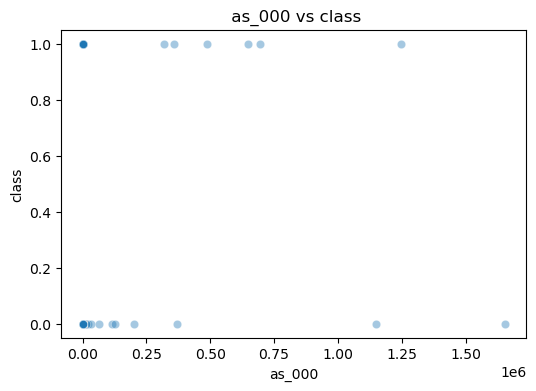

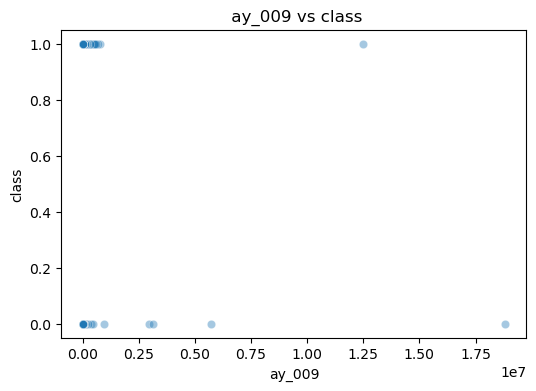

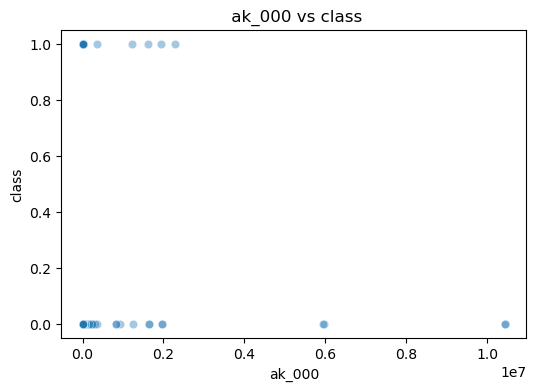

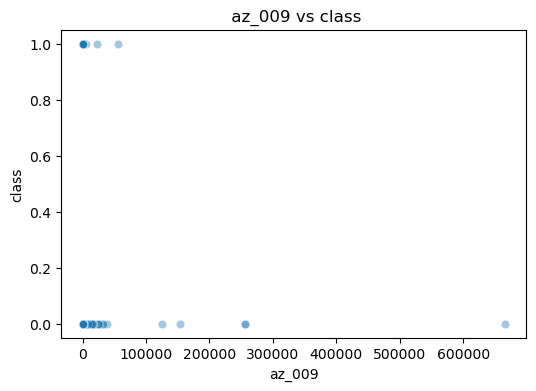

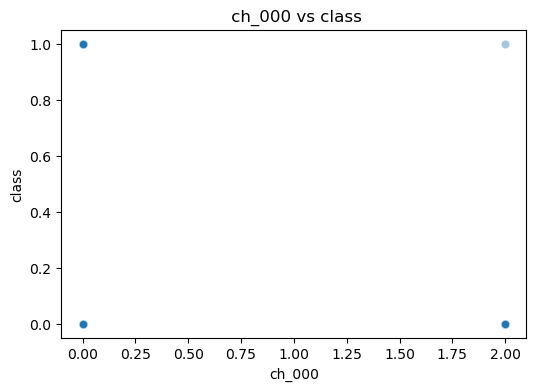

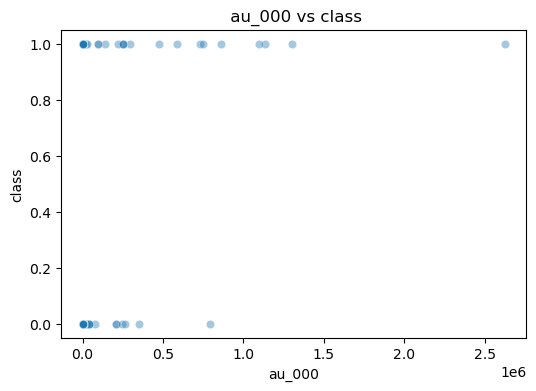

In [7]:
n=13###170**1/2 floor is 13
top_features = cv.sort_values(ascending=False).head(n).index.tolist()
for feature in top_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=trainDf, x=feature, y='class', alpha=0.4)
    plt.title(f" {feature} vs class")
    plt.xlabel(feature)
    plt.ylabel("class")
    plt.show()

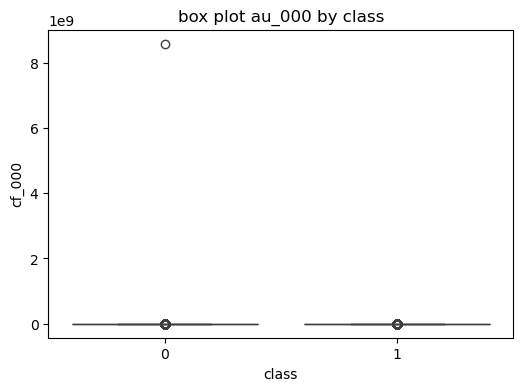

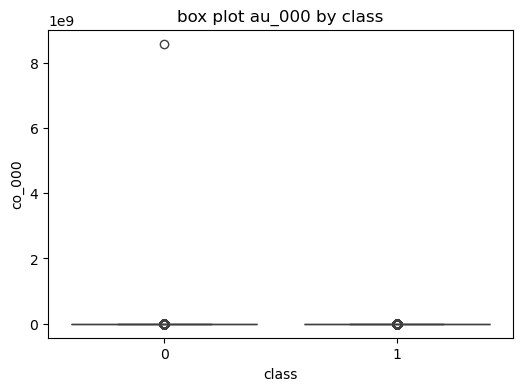

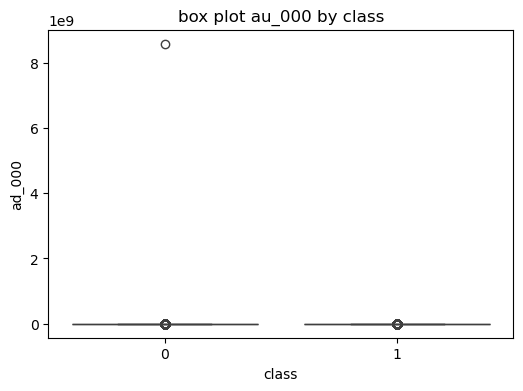

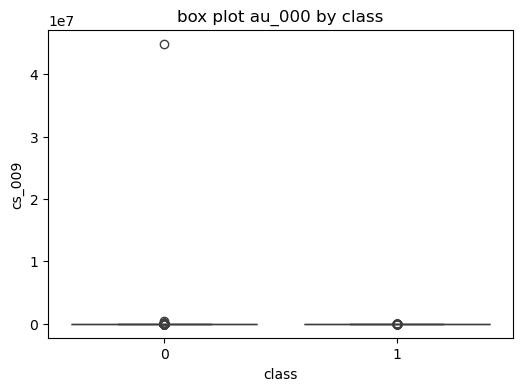

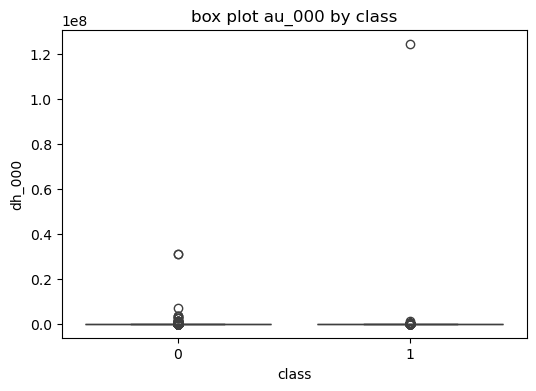

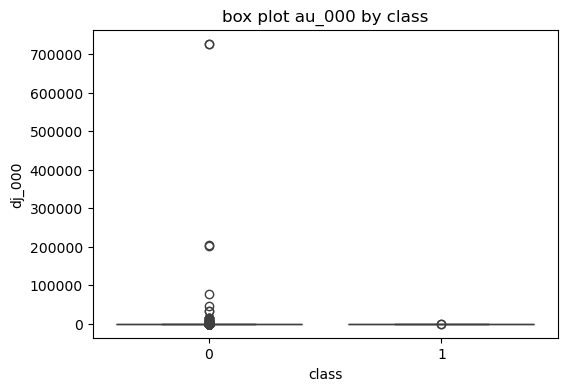

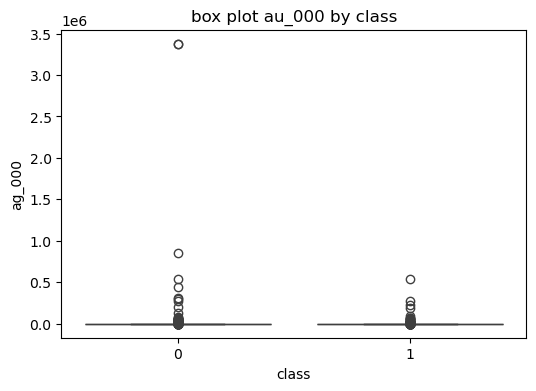

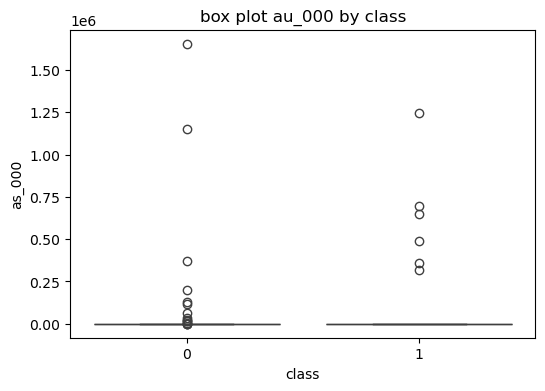

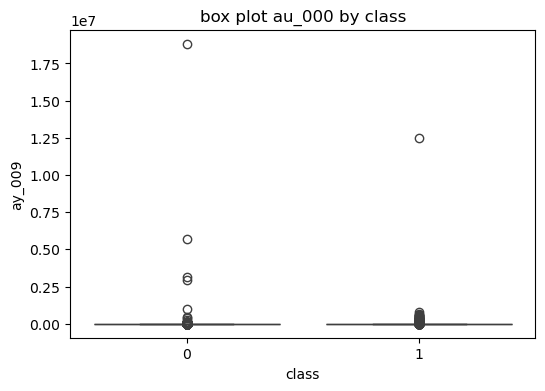

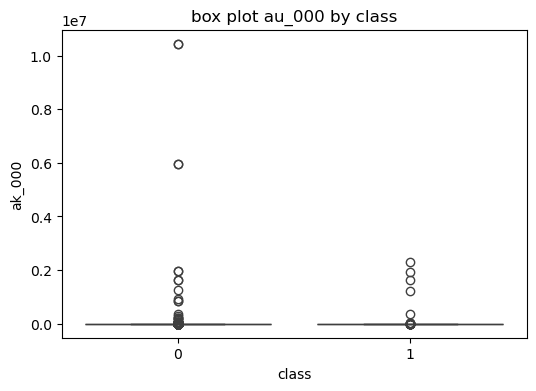

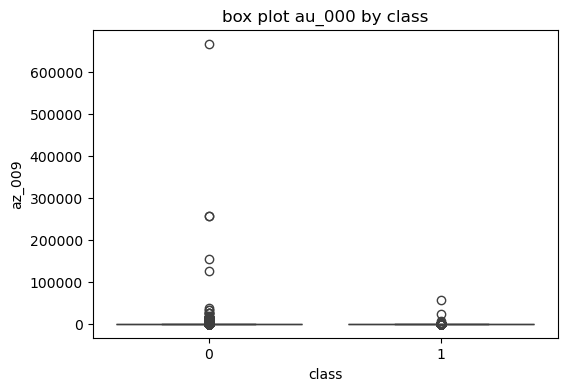

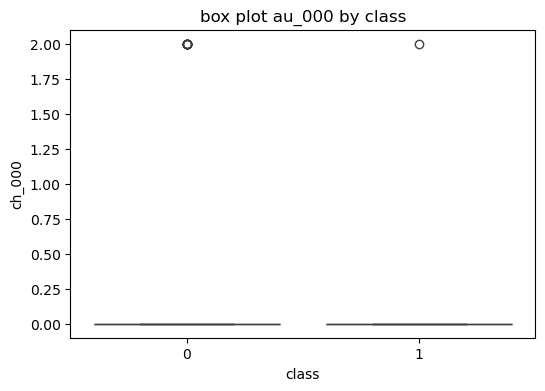

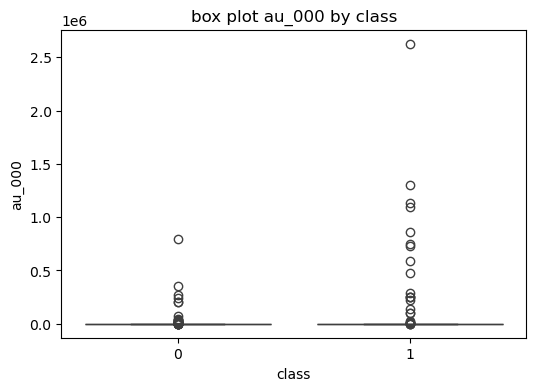

In [8]:
for f in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=trainDf, x='class', y=f)
    plt.title(f"box plot {feature} by class")
    plt.xlabel("class")
    plt.ylabel(f)
    plt.show()

No, one cannot conclude statistical significance by observing the scatter plots. Instead, one needs do statistical anaylsis.

#### (v) Is this data set imbalanced?

In [9]:
pos = (trainDf['class'] == 1).sum()
neg = (trainDf['class'] == 0).sum()
print(f'pos has {pos} instances, neg has {neg} instances')

pos has 1000 instances, neg has 59000 instances


It is not balanced, neg is more than pos.

### (c) Train a random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
X_train = trainDf.drop(columns=['class'])
y_train = trainDf['class']
X_test  = testDf.drop(columns=['class'])
y_test  = testDf['class']
rf = RandomForestClassifier(
    n_estimators=200,       
    max_depth=None,        
    max_features='sqrt',    
    min_samples_split=2,    
    oob_score=True,        
    n_jobs=-1,              
    random_state=42,
    class_weight=None        
)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [11]:
#predict
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

y_prob_train = rf.predict_proba(X_train)[:, 1]
y_prob_test  = rf.predict_proba(X_test)[:, 1]

#cm
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test  = confusion_matrix(y_test, y_pred_test)
print("confusion matrix (Train): ")
print(cm_train)
print("confusion matrix (Test): ")
print(cm_test)


#roc auc
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

print(f"AUC (Train): {auc_train}")
print(f"AUC (Test):  {auc_test}")

#accuaracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
mis_train = 1 - acc_train
mis_test  = 1 - acc_test
print(f"Train accuracy: {acc_train}, misclassification: {mis_train}")
print(f"Test  accuracy: {acc_test}, misclassification: {mis_test}")

oob_acc   = rf.oob_score_
oob_error = 1 - oob_acc
print(f"OOB Accuracy: {oob_acc:}, OOB Error: {oob_error:}")

confusion matrix (Train): 
[[59000     0]
 [    0  1000]]
confusion matrix (Test): 
[[15609    16]
 [  104   271]]
AUC (Train): 1.0
AUC (Test):  0.9943510186666668
Train accuracy: 1.0, misclassification: 0.0
Test  accuracy: 0.9925, misclassification: 0.007499999999999951
OOB Accuracy: 0.9941, OOB Error: 0.005900000000000016


### (d) Research class imbalance in random forest

In [12]:
rf2 = RandomForestClassifier(
    n_estimators=200,       
    max_depth=None,        
    max_features='sqrt',    
    min_samples_split=2,    
    oob_score=True,        
    n_jobs=-1,              
    random_state=42,
    class_weight='balanced'        
)
rf2.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [13]:
y_pred_train = rf2.predict(X_train)
y_pred_test  = rf2.predict(X_test)

y_prob_train = rf2.predict_proba(X_train)[:, 1]
y_prob_test  = rf2.predict_proba(X_test)[:, 1]
#cm
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test  = confusion_matrix(y_test, y_pred_test)
print("confusion matrix (Train): ")
print(cm_train)
print("confusion matrix (Test): ")
print(cm_test)


#roc auc
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

print(f"AUC (Train): {auc_train}")
print(f"AUC (Test):  {auc_test}")

#accuaracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
mis_train = 1 - acc_train
mis_test  = 1 - acc_test
print(f"Train accuracy: {acc_train}, misclassification: {mis_train}")
print(f"Test  accuracy: {acc_test}, misclassification: {mis_test}")

oob_acc   = rf2.oob_score_
oob_error = 1 - oob_acc
print(f"OOB Accuracy: {oob_acc:}, OOB Error: {oob_error:}")

confusion matrix (Train): 
[[59000     0]
 [    0  1000]]
confusion matrix (Test): 
[[15610    15]
 [  160   215]]
AUC (Train): 1.0
AUC (Test):  0.9930674346666668
Train accuracy: 1.0, misclassification: 0.0
Test  accuracy: 0.9890625, misclassification: 0.010937500000000044
OOB Accuracy: 0.9920833333333333, OOB Error: 0.007916666666666683


AUC and accuracy in test set decrease. However, recall increases.

### (e) XGBoost and Model Trees

In [24]:
import xgboost as xgb
scores = []
alist = [0,0.1,0.5,1,5]
for a in alist:
    model = xgb.XGBClassifier(
        n_estimators=200,          
        learning_rate=0.1,         
        max_depth=6,               
        subsample=0.8,             
        colsample_bytree=0.8,     
        random_state=42,           
        n_jobs=-1,                 
        eval_metric='auc',
        reg_alpha = a,
        reg_lambda=0.0      
    )
    model.fit(X_train,y_train)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    scores.append(score.mean())
alpha = alist[scores.index(max(scores))]####max(scores) is the train error

In [25]:
model = xgb.XGBClassifier(
    n_estimators=200,          
    learning_rate=0.1,         
    max_depth=6,               
    subsample=0.8,             
    colsample_bytree=0.8,     
    random_state=42,           
    n_jobs=-1,                 
    eval_metric='auc',
    reg_alpha = alpha,
    reg_lambda=0.0      
)
model.fit(X_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [26]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

y_prob_train = model.predict_proba(X_train)[:, 1]
y_prob_test  = model.predict_proba(X_test)[:, 1]
#error 
score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
errors = 1-score
trainerror = errors.mean()
test_accuracy = accuracy_score(y_test,y_pred_test)
testerror = 1-test_accuracy
print(f'for error, train: {trainerror}, test: {testerror}')

#cm
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test  = confusion_matrix(y_test, y_pred_test)
print("confusion matrix (Train): ")
print(cm_train)
print("confusion matrix (Test): ")
print(cm_test)


#roc auc
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

print(f"AUC (Train): {auc_train}")
print(f"AUC (Test):  {auc_test}")

for error, train: 0.00581666666666667, test: 0.006687499999999957
confusion matrix (Train): 
[[59000     0]
 [    2   998]]
confusion matrix (Test): 
[[15608    17]
 [   90   285]]
AUC (Train): 0.9999776016949153
AUC (Test):  0.996474368


### (f) Use SMOTE to pre-process your data

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

X = trainDf.drop(columns=['class'])
y = trainDf['class'].astype(int) 
X_test = testDf.drop(columns=['class'])
y_test = testDf['class'].astype(int)


pipe = Pipeline([
    ('smote', SMOTE(random_state=42)), 
    ('xgb', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.0,  
        n_jobs=-1,
        random_state=42
    ))
])


param_grid = {'xgb__reg_alpha': [0, 0.1, 0.5, 1, 2, 5, 10]} 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1)
grid.fit(X, y)

print("Best reg_alpha:", grid.best_params_['xgb__reg_alpha'])
print("Mean CV AUC:", grid.best_score_)


best_pipeline = grid.best_estimator_
best_pipeline.fit(X, y)


y_pred_test = best_pipeline.predict(X_test)
y_prob_test = best_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_prob_test)
cm = confusion_matrix(y_test, y_pred_test)



Best reg_alpha: 2
Mean CV AUC: 0.9877443644067796


In [23]:
print("Test Set Performance ")
print(f"Accuracy: {acc}")
print(f"AUC: {auc}")
print("Confusion Matrix:")
print(cm)

Test Set Performance 
Accuracy: 0.9933125
AUC: 0.9956160853333333
Confusion Matrix:
[[15578    47]
 [   60   315]]


smote case 's test set auc and accuracy are worse than that of imbalanced case, because in the test set, the pos is still minority.

## 2. ISLR 6.6.3

a:iv.  
b:ii.  
c:iii.  
d:iv.    
e:v.

## 3. ISLR 6.6.5

a  
$$
\min_{\beta_1, \beta_2} 
\left\{
\sum_{i=1}^{2} 
\left( y_i - \beta_1 x_{i1} - \beta_2 x_{i2} \right)^2
+ \lambda \left( \beta_1^2 + \beta_2^2 \right)
\right\}
$$

b  
Since \( x_{i1} = x_{i2} \) for both samples, the model really only cares about the sum \( \beta_1 + \beta_2 \).

Ridge adds an \( L_2 \) penalty \( \lambda(\beta_1^2 + \beta_2^2) \).  
For a fixed total \( \beta_1 + \beta_2 \), that penalty is smallest when the two are equal — it “splits” them evenly.  

So in the end:

$$
\hat{\beta}_1 = \hat{\beta}_2.
$$


c  
$$
\min_{\beta_1, \beta_2} 
\left\{
\sum_{i=1}^{2} 
\left( y_i - \beta_1 x_{i1} - \beta_2 x_{i2} \right)^2
+ \lambda \left( |\beta_1| + |\beta_2| \right)
\right\}
$$

d  
For lasso, the loss still only depends on \( \beta_1 + \beta_2 \), but the \( L_1 \) penalty \( |\beta_1| + |\beta_2| \) is flat whenever both have the same sign.

That means any pair that satisfies

$$
\beta_1 + \beta_2 = s^*, \quad \beta_1 \beta_2 \ge 0
$$

gives the same minimum.  
So the solution isn’t unique — you can have \( (\beta_1, \beta_2) = (s^*, 0) \), \( (0, s^*) \), or anything in between.


## 4. ISLR 8.4.5

for first approach, 6 out 10 vote for red, so it is red.  
for the second approach, the avg probability is 0.45, so it is green.

## 5. ISLR 9.7.3

a

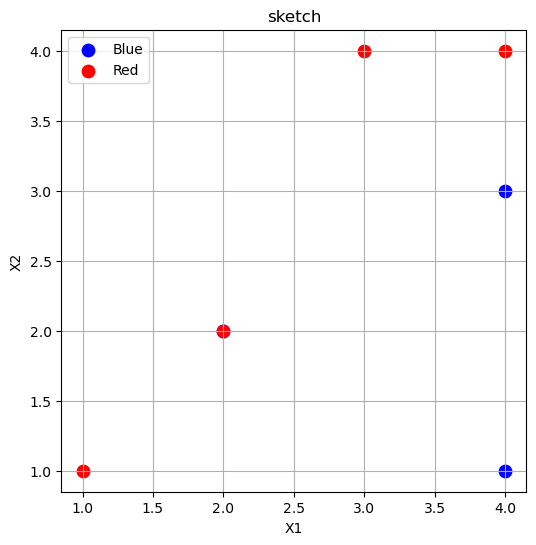

In [29]:
data = {
    'Obs': [1, 2, 3, 4, 5, 6, 7],
    'X1': [3, 2, 4, 1, 2, 4, 4],
    'X2': [4, 2, 4, 1, 2, 3, 1],
    'Y':  ['Red', 'Red', 'Red', 'Red', 'Blue', 'Blue', 'Blue']
}

df = pd.DataFrame(data)
plt.figure(figsize=(6,6))
colors = {'Red': 'red', 'Blue': 'blue'}

for label, group in df.groupby('Y'):
    plt.scatter(group['X1'], group['X2'], color=colors[label], label=label, s=80)

plt.xlabel('X1')
plt.ylabel('X2',)
plt.title('sketch')
plt.legend()
plt.grid(True)
plt.show()

b  
equation: x2-x1+1 = 0

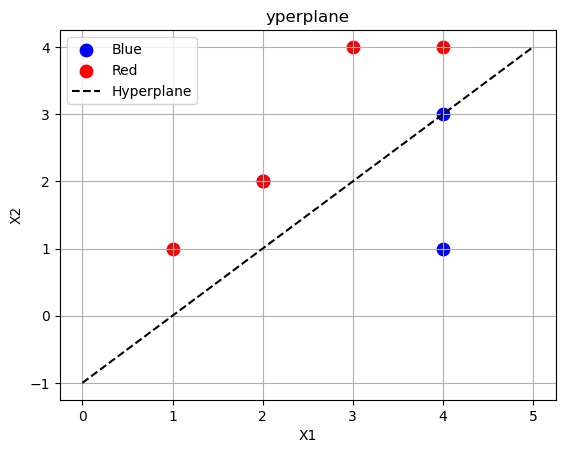

In [32]:
colors = {'Red': 'red', 'Blue': 'blue'}
for label, group in df.groupby('Y'):
    plt.scatter(group['X1'], group['X2'], color=colors[label], label=label, s=80)
x_vals = np.linspace(0, 5, 100)
y_vals = x_vals - 1
plt.plot(x_vals, y_vals, 'k--', label='Hyperplane')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('yperplane')
plt.legend()
plt.grid(True)
plt.show()

c  
x2-x1+1=0  
f(x1,x2) = beta0 + beta1x1 + beta2x2 = 1 -x1 +x2  
if f(x1,x2)>0, then red; else, blue

d  
x2​−x1​+1=+1 -> x2-x1=0  
x2-x1+1 = -1 -> x2-x1 = -2  


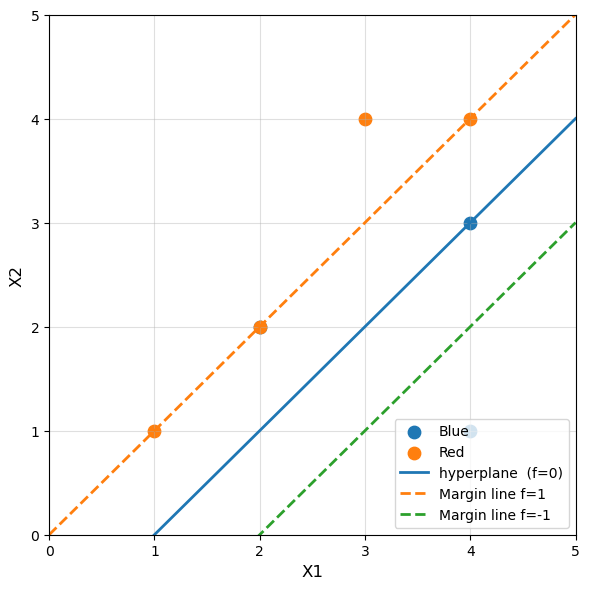

In [34]:
beta0, beta1, beta2 = 1, -1, 1

def f(x1, x2):
    return beta0 + beta1*x1 + beta2*x2


plt.figure(figsize=(6, 6))


for label, g in df.groupby('Y'):
    plt.scatter(g['X1'], g['X2'], s=80, label=label)


x = np.linspace(0, 5, 200)

y_sep = x - 1
plt.plot(x, y_sep, linewidth=2, label='hyperplane  (f=0)')


y_marg_pos = x
plt.plot(x, y_marg_pos, linestyle='--', linewidth=2, label='Margin line f=1')


y_marg_neg = x - 2
plt.plot(x, y_marg_neg, linestyle='--', linewidth=2, label='Margin line f=-1')

plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.grid(True, alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

e  
(2,2),(4,4),(1,1)

f  
it is not a support vector, so its lagrange multiplier is 0.

g  
x2-x1+0.8=0


h  
(3,4) blue